In [3]:
import os
import argparse
import torch
import random
from PIL import Image
from torchvision import utils as vutils
from torchvision import transforms
from efficient_vqgan import EfficientVQGAN
from utils import flexible_load_pretrained
import matplotlib.pyplot as plt

def load_image(image_path, image_size=256):
    image = Image.open(image_path)
    if not image.mode == "RGB":
        image = image.convert("RGB")
    
    transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # [-1, 1] 범위로 정규화
    ])
    
    image_tensor = transform(image).unsqueeze(0)
    return image_tensor


def show_reconstruction(original, reconstructed):
    """Replaces save_reconstruction: show side-by-side reconstruction instead of saving"""
    original = (original + 1) / 2
    reconstructed = (reconstructed + 1) / 2
    batch_size = original.size(0)
    comparison = torch.cat([original, reconstructed], dim=0)

    grid = vutils.make_grid(comparison, nrow=batch_size, padding=2, normalize=False)
    npimg = grid.numpy().transpose((1, 2, 0))
    plt.figure(figsize=(12, 6))
    plt.imshow(npimg)
    plt.axis("off")
    plt.title("Original (top) vs Reconstructed (bottom)")
    plt.show()


def reconstruct_single_image(model, image_path, save_path, device):
    image = load_image(image_path, image_size=model.decoder.to_rgb.in_channels * 64)

    image = image.to(device)
    with torch.no_grad():
        reconstructed, indices, _ = model(image)
    show_reconstruction(image.cpu(), reconstructed.cpu())
    unique_indices = torch.unique(indices)
    print(f"Used {len(unique_indices)} / {model.codebook.K} codebook entries")
    return reconstructed


def reconstruct_from_directory(model, input_dir, output_dir, device, max_images=None, batch_size=4, num_iterations=None):
    os.makedirs(output_dir, exist_ok=True)
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
    image_files = [
        f for f in os.listdir(input_dir)
        if os.path.splitext(f.lower())[1] in image_extensions
    ]
    if max_images is not None:
        image_files = image_files[:max_images]
    print(f"Processing {len(image_files)} images from {input_dir}")

    iteration_count = 0
    for batch_idx in range(0, len(image_files), batch_size):
        if num_iterations is not None and iteration_count >= num_iterations:
            print(f"Reached maximum iterations ({num_iterations}). Stopping.")
            break

        iteration_count += 1
        batch_files = image_files[batch_idx:batch_idx + batch_size]
        originals = []
        reconstructed_list = []
        
        for img_file in batch_files:
            input_path = os.path.join(input_dir, img_file)
            try:
                image = load_image(input_path, image_size=256)
                image = image.to(device)
                
                with torch.no_grad():
                    reconstructed, indices, _ = model(image)
                
                originals.append(image.cpu())
                reconstructed_list.append(reconstructed.cpu())
                
                unique_indices = torch.unique(indices)
                print(f"{img_file}: Used {len(unique_indices)} / {model.codebook.K} codebook entries")
                
            except Exception as e:
                print(f"Error processing {img_file}: {e}")
        
        if originals:
            originals_batch = torch.cat(originals, dim=0)
            reconstructed_batch = torch.cat(reconstructed_list, dim=0)
            output_path = os.path.join(output_dir, f"batch_{batch_idx // batch_size + 1}_reconstruction.png")
            show_reconstruction(originals_batch, reconstructed_batch)


def reconstruct_random_images(model, input_dir, output_path, device, num_images=4, image_size=256):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
    image_files = [
        f for f in os.listdir(input_dir)
        if os.path.splitext(f.lower())[1] in image_extensions
    ]
    
    if len(image_files) == 0:
        raise ValueError(f"No images found in {input_dir}")
    
    selected_files = random.sample(image_files, min(num_images, len(image_files)))
    print(f"Randomly selected {len(selected_files)} images from {input_dir}:")
    for f in selected_files:
        print(f"  - {f}")
    
    originals = []
    reconstructed_list = []
    
    for img_file in selected_files:
        input_path = os.path.join(input_dir, img_file)
        try:
            image = load_image(input_path, image_size=image_size)
            image = image.to(device)
            
            with torch.no_grad():
                reconstructed, indices, _ = model(image)
            
            originals.append(image.cpu())
            reconstructed_list.append(reconstructed.cpu())
            
            unique_indices = torch.unique(indices)
            print(f"{img_file}: Used {len(unique_indices)} / {model.codebook.K} codebook entries")
            
        except Exception as e:
            print(f"Error processing {img_file}: {e}")
    
    if originals:
        originals_batch = torch.cat(originals, dim=0)
        reconstructed_batch = torch.cat(reconstructed_list, dim=0)
        show_reconstruction(originals_batch, reconstructed_batch, output_path)
        print(f"\nVisualization complete! Saved to {output_path}")
    else:
        print("No images were successfully processed.")


def main(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    print("Initializing VQGAN model...")
    model = EfficientVQGAN(args).to(device)
    model.eval()
    if not os.path.exists(args.checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {args.checkpoint_path}")
    print(f"Loading pretrained weights from {args.checkpoint_path}")
    loaded_params = flexible_load_pretrained(
        model,
        ckpt_path=args.checkpoint_path,
        do_depth_surgery=True,
        interp_rpb=True,
        device=device,
        verbose=True
    )
    print(f"Loaded {len(loaded_params)} parameters from checkpoint")
    if args.random_sample:
        input_dir = args.input_dir or "data/imagenet"
        output_path = os.path.join(args.output_dir, "visualization_result.jpg")
        print(f"Randomly sampling {args.num_samples} images from {input_dir}")
        reconstruct_random_images(
            model, input_dir, output_path, device, 
            num_images=args.num_samples, image_size=args.image_size
        )
    elif args.input_image:
        print(f"Processing single image: {args.input_image}")
        output_path = args.output_path or "reconstruction_result.png"
        reconstruct_single_image(model, args.input_image, output_path, device)
    elif args.input_dir:
        output_dir = args.output_dir or "reconstruction_results"
        reconstruct_from_directory(
            model, args.input_dir, output_dir, device, args.max_images, 
            args.batch_size, args.num_iterations
        )
    else:
        print("Please specify either --input_image, --input_dir, or --random_sample")

/opt/conda/lib/python3.11/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 500: named symbol not found (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0
/opt/conda/lib/python3.11/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Using device: cpu
Initializing VQGAN model...
Loading pretrained weights from checkpoints/conv3_last.pt
[FlexibleLoad] Initialized decoder.residual_block.patch_embed.proj.weight as identity
[FlexibleLoad] Initialized decoder.residual_block.patch_embed.proj.bias as zero
[FlexibleLoad] loaded tensors: 221
Loaded 221 parameters from checkpoint
Processing 428 images from data/archive/arctic_fox
000.jpg: Used 201 / 1024 codebook entries
001.jpg: Used 165 / 1024 codebook entries


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.096667886..1.1206117].


002.jpg: Used 177 / 1024 codebook entries
003.jpg: Used 151 / 1024 codebook entries


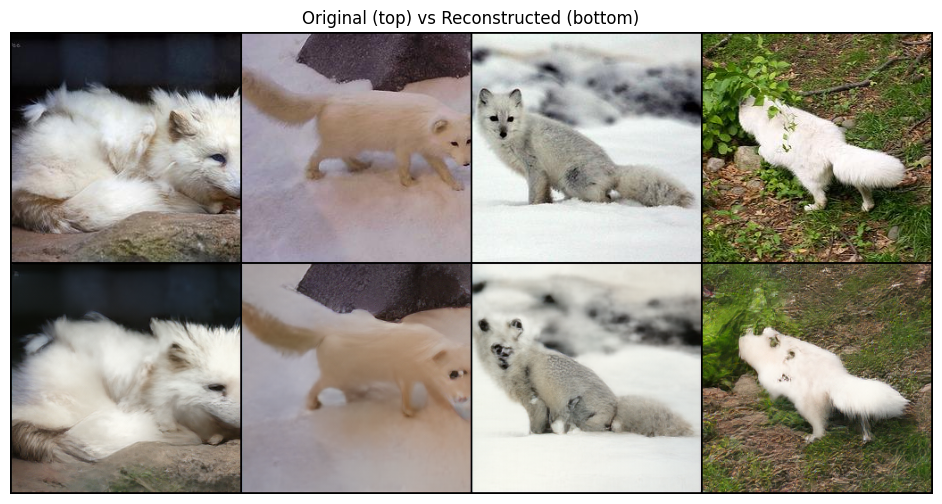

004.jpg: Used 151 / 1024 codebook entries
005.jpg: Used 200 / 1024 codebook entries


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.030115485..1.1802707].


006.jpg: Used 197 / 1024 codebook entries
007.jpg: Used 172 / 1024 codebook entries


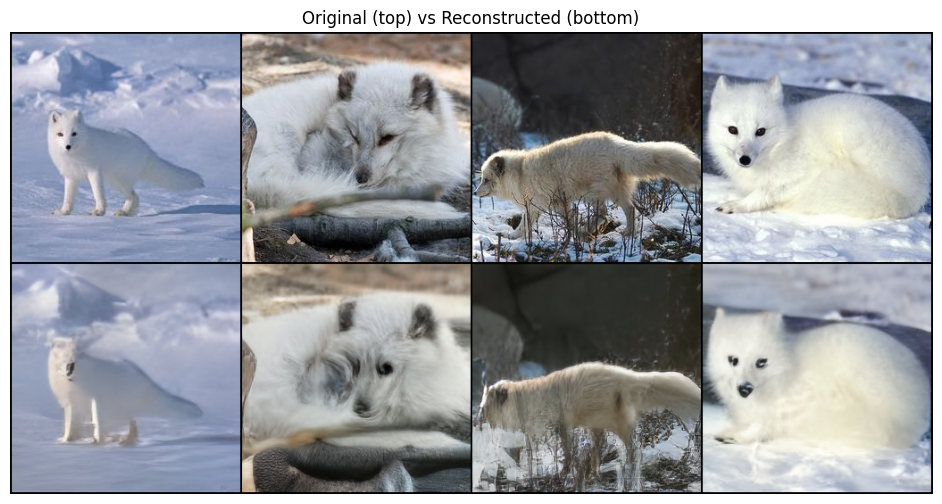

008.jpg: Used 204 / 1024 codebook entries
009.jpg: Used 164 / 1024 codebook entries


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13528514..1.0981095].


010.jpg: Used 162 / 1024 codebook entries
011.jpg: Used 202 / 1024 codebook entries


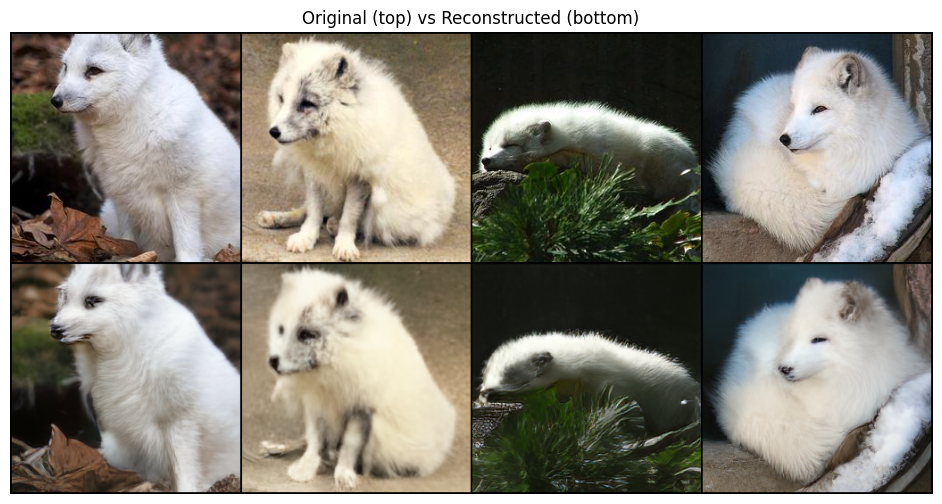

Reached maximum iterations (3). Stopping.


In [4]:
if __name__ == '__main__':
    parser = argparse.ArgumentParser(description="VQGAN Reconstruction Inference")
    parser.add_argument('--image-size', type=int, default=256)
    parser.add_argument('--image-channels', type=int, default=3)
    parser.add_argument('--num-codebook-vectors', type=int, default=1024)
    parser.add_argument('--latent-dim', type=int, default=1024)
    parser.add_argument('--beta', type=float, default=0.25)
    parser.add_argument('--checkpoint-path', type=str, default="checkpoints/conv3_last.pt")
    parser.add_argument('--input-image', type=str, default=None)
    parser.add_argument('--input-dir', type=str, default="data/archive/arctic_fox")
    parser.add_argument('--output-path', type=str, default=None)
    parser.add_argument('--output-dir', type=str, default='reconstruction_results')
    parser.add_argument('--max-images', type=int, default=None)
    parser.add_argument('--batch-size', type=int, default=4)
    parser.add_argument('--num-iterations', type=int, default=3)
    parser.add_argument('--random-sample', action='store_true')
    parser.add_argument('--num-samples', type=int, default=4)
    
    # ✅ 핵심 수정
    args, _ = parser.parse_known_args()
    main(args)
